In [6]:
#task 1
import pandas as pd

aqi = pd.read_csv("/content/city_day.csv")
crop = pd.read_csv("/content/crop_production.csv")

print(aqi.shape)
print(aqi.info())
print(aqi.describe())

print(crop.shape)
print(crop.info())
print(crop.describe())

print(aqi.isnull().sum())
print(crop.isnull().sum())

print(aqi.duplicated().sum())
print(crop.duplicated().sum())

(29531, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB
None
              PM2.5          PM10            NO           NO2           NOx  \
coun

In [3]:
print("AQI Duplicate Records:", aqi.duplicated().sum())
print("Crop Duplicate Records:", crop.duplicated().sum())

AQI Duplicate Records: 0
Crop Duplicate Records: 9717


In [8]:
aqi.isnull().sum()

,0
City,0
Date,0
PM2.5,0
PM10,0
NO,0
NO2,0
NOx,0
NH3,0
CO,0
SO2,0


In [12]:
#task 2
num_cols = [
'PM2.5','PM10','NO','NO2',
'NOx','NH3','CO','SO2',
'O3','Benzene','Toluene','AQI'
]

for col in num_cols:
    aqi[col] = aqi[col].fillna(aqi[col].median())

aqi['AQI_Bucket'] = aqi['AQI_Bucket'].fillna(
    aqi['AQI_Bucket'].mode()[0]
)

crop['Production'] = crop['Production'].fillna(
    crop['Production'].median()
)

crop.dropna(inplace=True)

In [13]:
#task 2
print("AQI Missing Values")
print(aqi.isnull().sum())

print("\nCrop Missing Values")
print(crop.isnull().sum())

AQI Missing Values
City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
AQI           0
AQI_Bucket    0
dtype: int64

Crop Missing Values
State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
dtype: int64


In [14]:
#task 3
aqi_before = len(aqi)
crop_before = len(crop)

print("AQI Records Before:", aqi_before)
print("Crop Records Before:", crop_before)

AQI Records Before: 29531
Crop Records Before: 255808


In [15]:
#task 3
aqi.drop_duplicates(inplace=True)
crop.drop_duplicates(inplace=True)

In [16]:
#task 3
aqi_after = len(aqi)
crop_after = len(crop)

print("AQI Records After:", aqi_after)
print("Crop Records After:", crop_after)

print("AQI Duplicates Removed:", aqi_before - aqi_after)
print("Crop Duplicates Removed:", crop_before - crop_after)

AQI Records After: 29531
Crop Records After: 246091
AQI Duplicates Removed: 0
Crop Duplicates Removed: 9717


In [17]:
#task 3
crop['State_Name'] = (
    crop['State_Name']
    .str.strip()
    .str.title()
)

In [18]:
#task 3
print(sorted(crop['State_Name'].unique()))

['Andaman And Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra And Nagar Haveli', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu And Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


In [19]:
#task 4
import matplotlib.pyplot as plt
import seaborn as sns

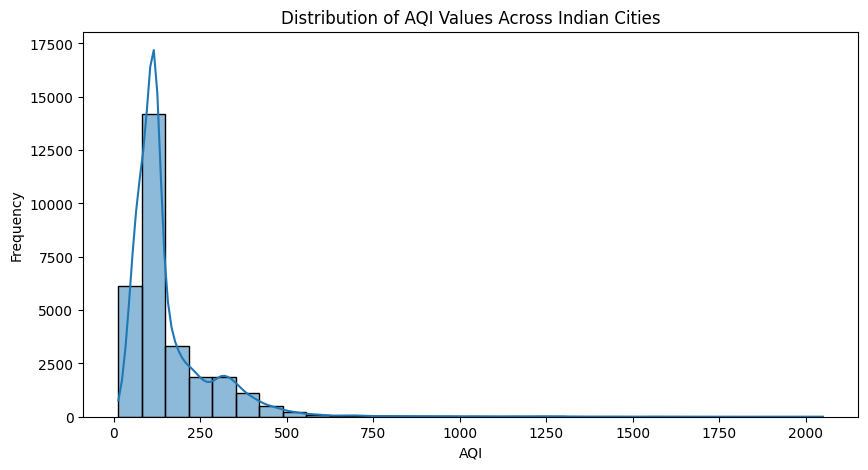

In [20]:
#task 4
plt.figure(figsize=(10,5))

sns.histplot(aqi['AQI'], bins=30, kde=True)

plt.title("Distribution of AQI Values Across Indian Cities")
plt.xlabel("AQI")
plt.ylabel("Frequency")

plt.show()

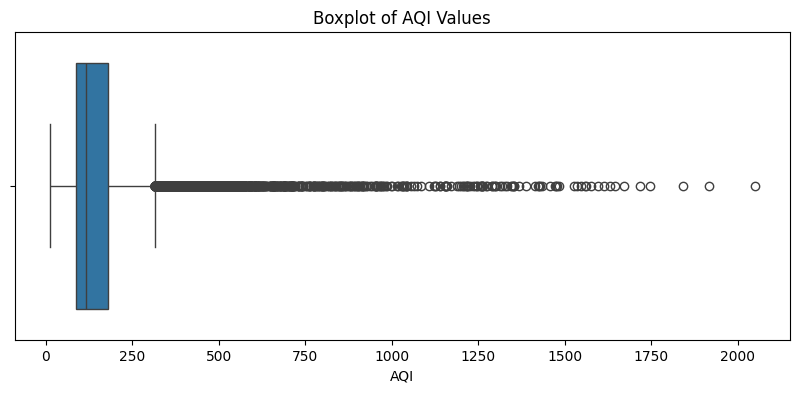

In [21]:
#task 4
plt.figure(figsize=(10,4))

sns.boxplot(x=aqi['AQI'])

plt.title("Boxplot of AQI Values")

plt.show()

In [22]:
print("Mean AQI:", round(aqi['AQI'].mean(),2))
print("Median AQI:", round(aqi['AQI'].median(),2))

Mean AQI: 158.78
Median AQI: 118.0


In [24]:
#task 5
Q1 = aqi['AQI'].quantile(0.25)
Q3 = aqi['AQI'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 88.0
Q3: 179.0
IQR: 91.0
Lower Bound: -48.5
Upper Bound: 315.5


In [25]:
#task 5
outliers = aqi[
    (aqi['AQI'] < lower_bound) |
    (aqi['AQI'] > upper_bound)
]

print("Number of Outliers:", len(outliers))

Number of Outliers: 3192


In [26]:
#task 5
aqi_before = aqi.copy()

In [27]:
#task 5
aqi['AQI'] = aqi['AQI'].clip(
    lower=lower_bound,
    upper=upper_bound
)

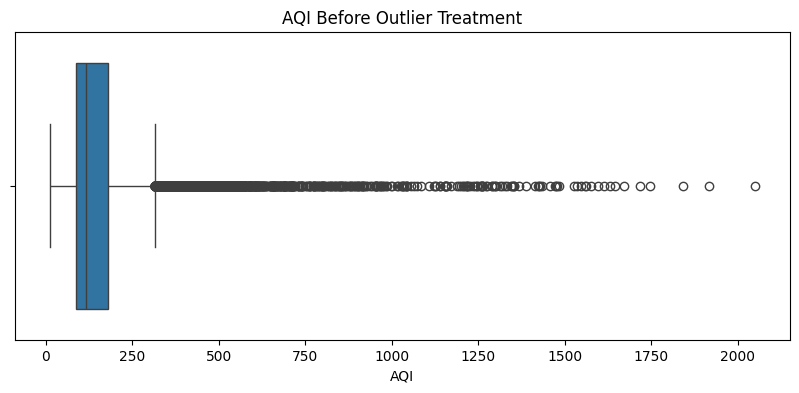

In [28]:
plt.figure(figsize=(10,4))

sns.boxplot(x=aqi_before['AQI'])

plt.title("AQI Before Outlier Treatment")

plt.show()

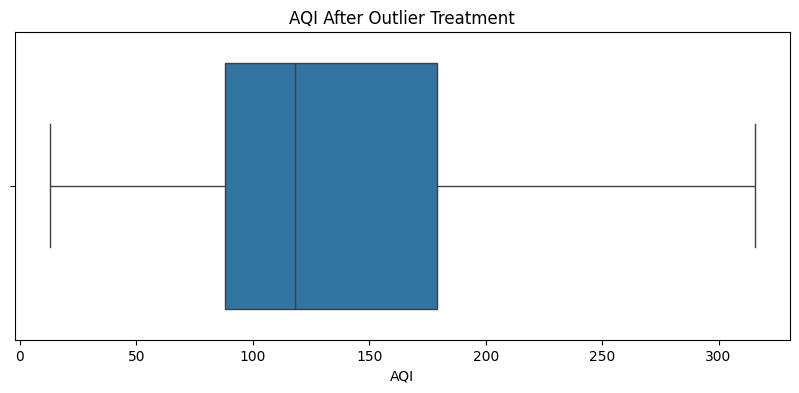

In [30]:
#task 5
plt.figure(figsize=(10,4))

sns.boxplot(x=aqi['AQI'])

plt.title("AQI After Outlier Treatment")

plt.show()

In [31]:
new_outliers = aqi[
    (aqi['AQI'] < lower_bound) |
    (aqi['AQI'] > upper_bound)
]

print("Outliers Remaining:", len(new_outliers))

Outliers Remaining: 0


In [3]:
#Lab 2
import pandas as pd


In [7]:
#task 6
aqi['Date'] = pd.to_datetime(aqi['Date'])

In [10]:
#task 6
aqi['Year'] = aqi['Date'].dt.year
print(aqi[['Date','Year']].head())

        Date  Year
0 2015-01-01  2015
1 2015-01-02  2015
2 2015-01-03  2015
3 2015-01-04  2015
4 2015-01-05  2015


In [11]:
#task 6
yearly_aqi = aqi.groupby('Year')['AQI'].mean()

print(yearly_aqi)

Year
2015    212.463054
2016    197.150019
2017    181.472789
2018    182.684312
2019    156.518173
2020    113.520697
Name: AQI, dtype: float64


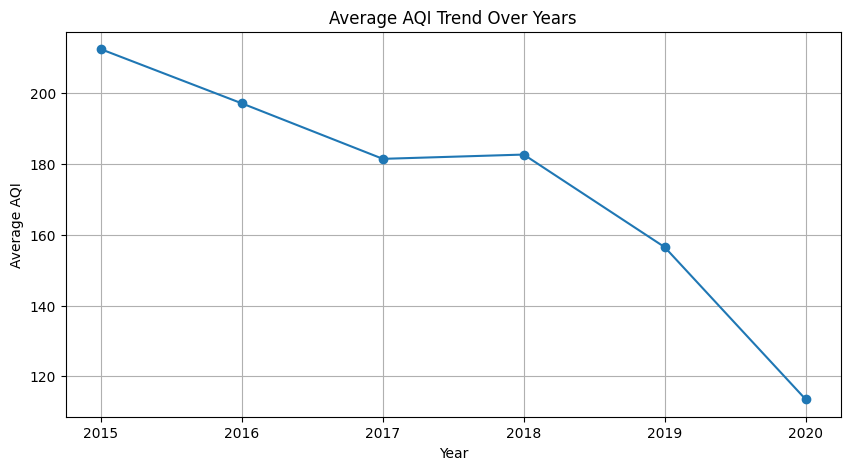

In [12]:
# task 6
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

yearly_aqi.plot(marker='o')

plt.title("Average AQI Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Average AQI")

plt.grid(True)

plt.show()

In [13]:
#task 6
most_polluted_year = yearly_aqi.idxmax()
least_polluted_year = yearly_aqi.idxmin()

print("Most Polluted Year:", most_polluted_year)
print("AQI:", yearly_aqi.max())

print()

print("Least Polluted Year:", least_polluted_year)
print("AQI:", yearly_aqi.min())

Most Polluted Year: 2015
AQI: 212.4630541871921

Least Polluted Year: 2020
AQI: 113.52069667496042


In [14]:
#task 7
#step 1
aqi['Month'] = aqi['Date'].dt.month

monthly_aqi = aqi.groupby('Month')['AQI'].mean()

print(monthly_aqi)

Month
1     231.674918
2     202.905197
3     164.735281
4     143.355120
5     135.489579
6     120.198379
7     111.854575
8     113.613176
9     115.191804
10    188.613552
11    241.681302
12    227.084980
Name: AQI, dtype: float64


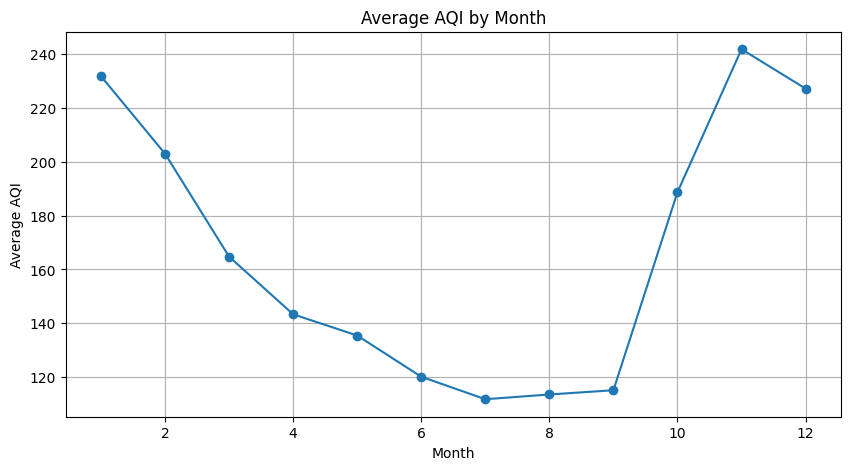

In [15]:
plt.figure(figsize=(10,5))

monthly_aqi.plot(marker='o')

plt.title("Average AQI by Month")
plt.xlabel("Month")
plt.ylabel("Average AQI")

plt.grid(True)

plt.show()

In [16]:
print(aqi.columns)

Index(['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2',
       'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket', 'Year',
       'Month'],
      dtype='object')


In [17]:
print("Number of Cities:", aqi['City'].nunique())

print(sorted(aqi['City'].unique()))

Number of Cities: 26
['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru', 'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore', 'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad', 'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai', 'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram', 'Visakhapatnam']


In [18]:
city_to_state = {
    'Ahmedabad':'Gujarat',
    'Aizawl':'Mizoram',
    'Amaravati':'Andhra Pradesh',
    'Amritsar':'Punjab',
    'Bengaluru':'Karnataka',
    'Bhopal':'Madhya Pradesh',
    'Brajrajnagar':'Odisha',
    'Chandigarh':'Chandigarh',
    'Chennai':'Tamil Nadu',
    'Coimbatore':'Tamil Nadu',
    'Delhi':'Delhi',
    'Ernakulam':'Kerala',
    'Gurugram':'Haryana',
    'Guwahati':'Assam',
    'Hyderabad':'Telangana',
    'Jaipur':'Rajasthan',
    'Jorapokhar':'Jharkhand',
    'Kochi':'Kerala',
    'Kolkata':'West Bengal',
    'Lucknow':'Uttar Pradesh',
    'Mumbai':'Maharashtra',
    'Patna':'Bihar',
    'Shillong':'Meghalaya',
    'Talcher':'Odisha',
    'Thiruvananthapuram':'Kerala',
    'Visakhapatnam':'Andhra Pradesh'
}

In [19]:
aqi['State'] = aqi['City'].map(city_to_state)

print(aqi[['City','State']].head())

        City    State
0  Ahmedabad  Gujarat
1  Ahmedabad  Gujarat
2  Ahmedabad  Gujarat
3  Ahmedabad  Gujarat
4  Ahmedabad  Gujarat


In [20]:
state_aqi = (
    aqi.groupby(['State','Year'])['AQI']
    .mean()
    .reset_index()
)

state_aqi.head()

,State,Year,AQI
0,Andhra Pradesh,2016,103.976048
1,Andhra Pradesh,2017,152.423469
2,Andhra Pradesh,2018,112.340125
3,Andhra Pradesh,2019,111.578462
4,Andhra Pradesh,2020,72.110803


In [21]:
state_crop = (
    crop.groupby(['State_Name','Crop_Year'])
    [['Area','Production']]
    .sum()
    .reset_index()
)

state_crop.head()

,State_Name,Crop_Year,Area,Production
0,Andaman and Nicobar Islands,2000,44518.00,89060914.00
1,Andaman and Nicobar Islands,2001,41163.00,89718700.00
2,Andaman and Nicobar Islands,2002,45231.40,94387137.67
3,Andaman and Nicobar Islands,2003,44799.40,95296454.67
4,Andaman and Nicobar Islands,2004,45308.77,87186497.63


In [22]:
print("AQI Years:")
print(sorted(state_aqi['Year'].unique()))

print("\nCrop Years:")
print(sorted(state_crop['Crop_Year'].unique()))

AQI Years:
[np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020)]

Crop Years:
[np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015)]


In [23]:
state_crop_2015 = state_crop[
    state_crop['Crop_Year'] == 2015
]

state_crop_2015.head()

,State_Name,Crop_Year,Area,Production
349,Odisha,2015,4535445.0,6831648.7
416,Sikkim,2015,65853.0,103416.0


In [24]:
merged = pd.merge(
    state_aqi,
    state_crop_2015,
    left_on=['State','Year'],
    right_on=['State_Name','Crop_Year'],
    how='inner'
)

print("Merged Shape:", merged.shape)

merged.head()

Merged Shape: (0, 7)


,State,Year,AQI,State_Name,Crop_Year,Area,Production


In [25]:
print("Merged Shape:", merged.shape)

Merged Shape: (0, 7)


In [26]:
print(sorted(state_aqi['State'].unique()))

['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Delhi', 'Gujarat', 'Haryana', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Mizoram', 'Odisha', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh', 'West Bengal']


In [27]:
print(sorted(state_crop_2015['State_Name'].unique()))

['Odisha', 'Sikkim']


In [28]:
state_aqi[state_aqi['State'] == 'Odisha']

,State,Year,AQI
58,Odisha,2017,247.600000
59,Odisha,2018,169.723447
60,Odisha,2019,158.398400
61,Odisha,2020,150.389892


In [29]:
state_crop_2015[state_crop_2015['State_Name'] == 'Odisha']

,State_Name,Crop_Year,Area,Production
349,Odisha,2015,4535445.0,6831648.7


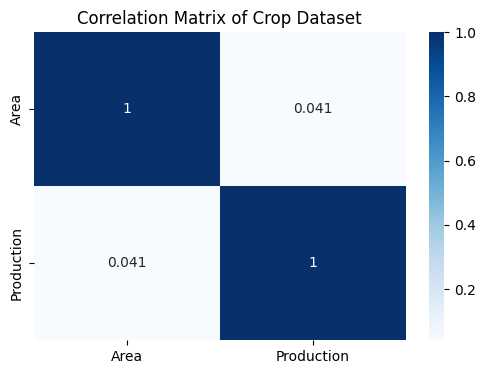

In [30]:
# task 8
import seaborn as sns
import matplotlib.pyplot as plt

corr = crop[['Area','Production']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='Blues')

plt.title("Correlation Matrix of Crop Dataset")

plt.show()